<a href="https://colab.research.google.com/github/fernandezsophia520/QLC_140G_SP26/blob/main/Coding_Exercise_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# coding exercise 3

- import a SSH (sea surface height) file and plot the SSH on a map

-Export figure and print for class


In [28]:
#import packages
#pandas, numpy, matplotlib, seaborn, cartopy.crs and cartopy.feature

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as ssrs
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import scipy.interpolate as interp

In [2]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 82.9 MB/s eta 0:00:00


In [14]:
df_ssh = pd.read_csv('/ssh_practicedata.csv')

In [15]:
display(df_ssh.head(15))

,lat,lon,ssh
0,20,-80,0.12
1,20,-75,0.15
2,20,-70,0.18
3,20,-65,0.22
4,20,-60,0.25
5,20,-55,0.28
6,20,-50,0.30
7,25,-80,0.10
8,25,-75,0.14
9,25,-70,0.20


Figure exported as 'ssh_contour_map.png'


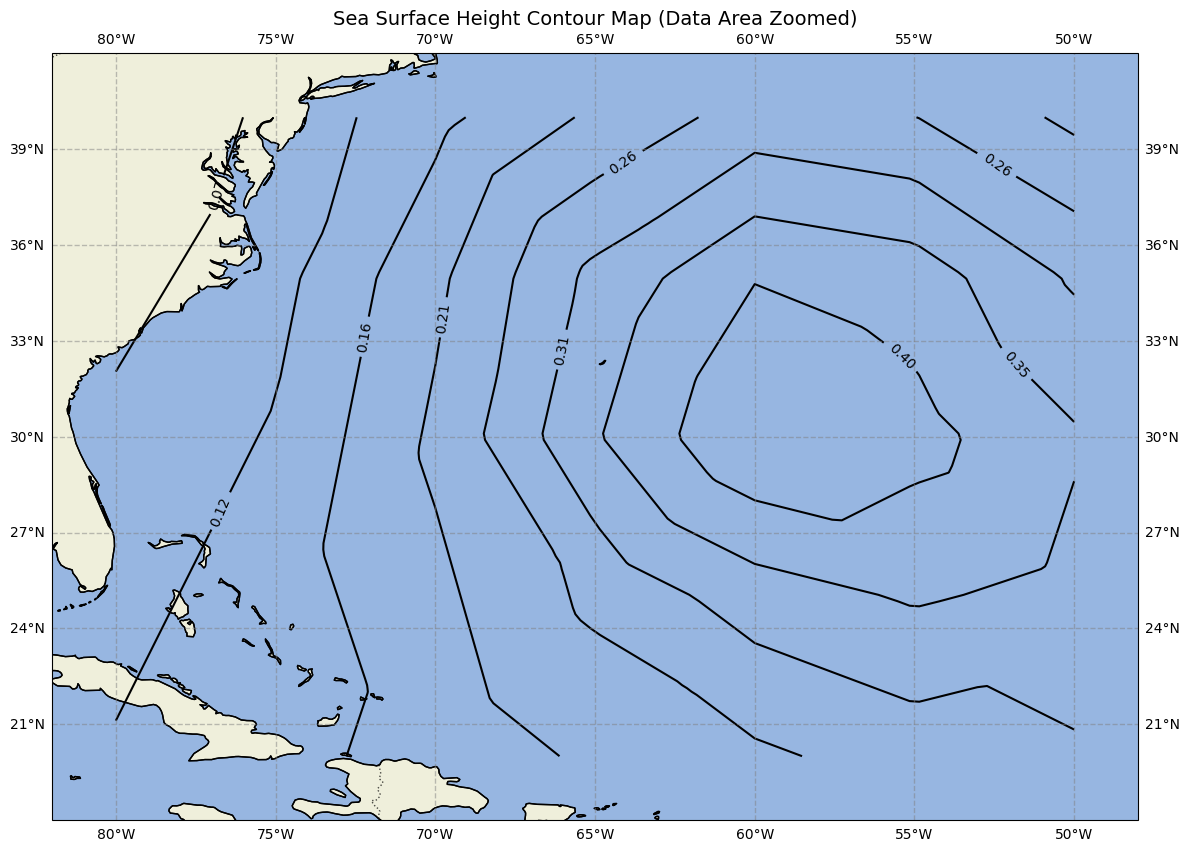

In [31]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.LAND, edgecolor='black', zorder=1)
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.COASTLINE, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.7, zorder=2)

# Set the extent to focus on the area with data points
lon_min, lon_max = df_ssh['lon'].min(), df_ssh['lon'].max()
lat_min, lat_max = df_ssh['lat'].min(), df_ssh['lat'].max()
# Adding a small buffer around the data points for better visualization
ax.set_extent([lon_min - 2, lon_max + 2, lat_min - 2, lat_max + 2], crs=ccrs.PlateCarree())

# Prepare data for contour plot
# Create a grid with a reasonable resolution, e.g., 100x100 points
lon_grid = np.linspace(lon_min, lon_max, 100)
lat_grid = np.linspace(lat_min, lat_max, 100)
xi, yi = np.meshgrid(lon_grid, lat_grid)

# Interpolate the SSH data onto the new grid
points = df_ssh[['lon', 'lat']].values
values = df_ssh['ssh'].values
zi = interp.griddata(points, values, (xi, yi), method='linear')

# Define contour levels - you might want to adjust these based on your data range
levels = np.linspace(df_ssh['ssh'].min(), df_ssh['ssh'].max(), 10) # 10 contour lines

# Plot the SSH data as a contour plot with no color shaping (single color)
contour = ax.contour(xi, yi, zi, levels=levels, colors='black', transform=ccrs.PlateCarree(), linewidths=1.5)

# Label the contours
ax.clabel(contour, inline=True, fontsize=10, fmt='%1.2f')

# Set title and labels
ax.set_title('Sea Surface Height Contour Map (Data Area Zoomed)', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Add gridlines
gridlines = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gridlines.xlabels_top = False
gridlines.ylabels_right = False

plt.tight_layout()

# Export the image
plt.savefig('ssh_contour_map.png', dpi=300, bbox_inches='tight')
print("Figure exported as 'ssh_contour_map.png'")

plt.show()

In [ ]:
#export figure to download and print


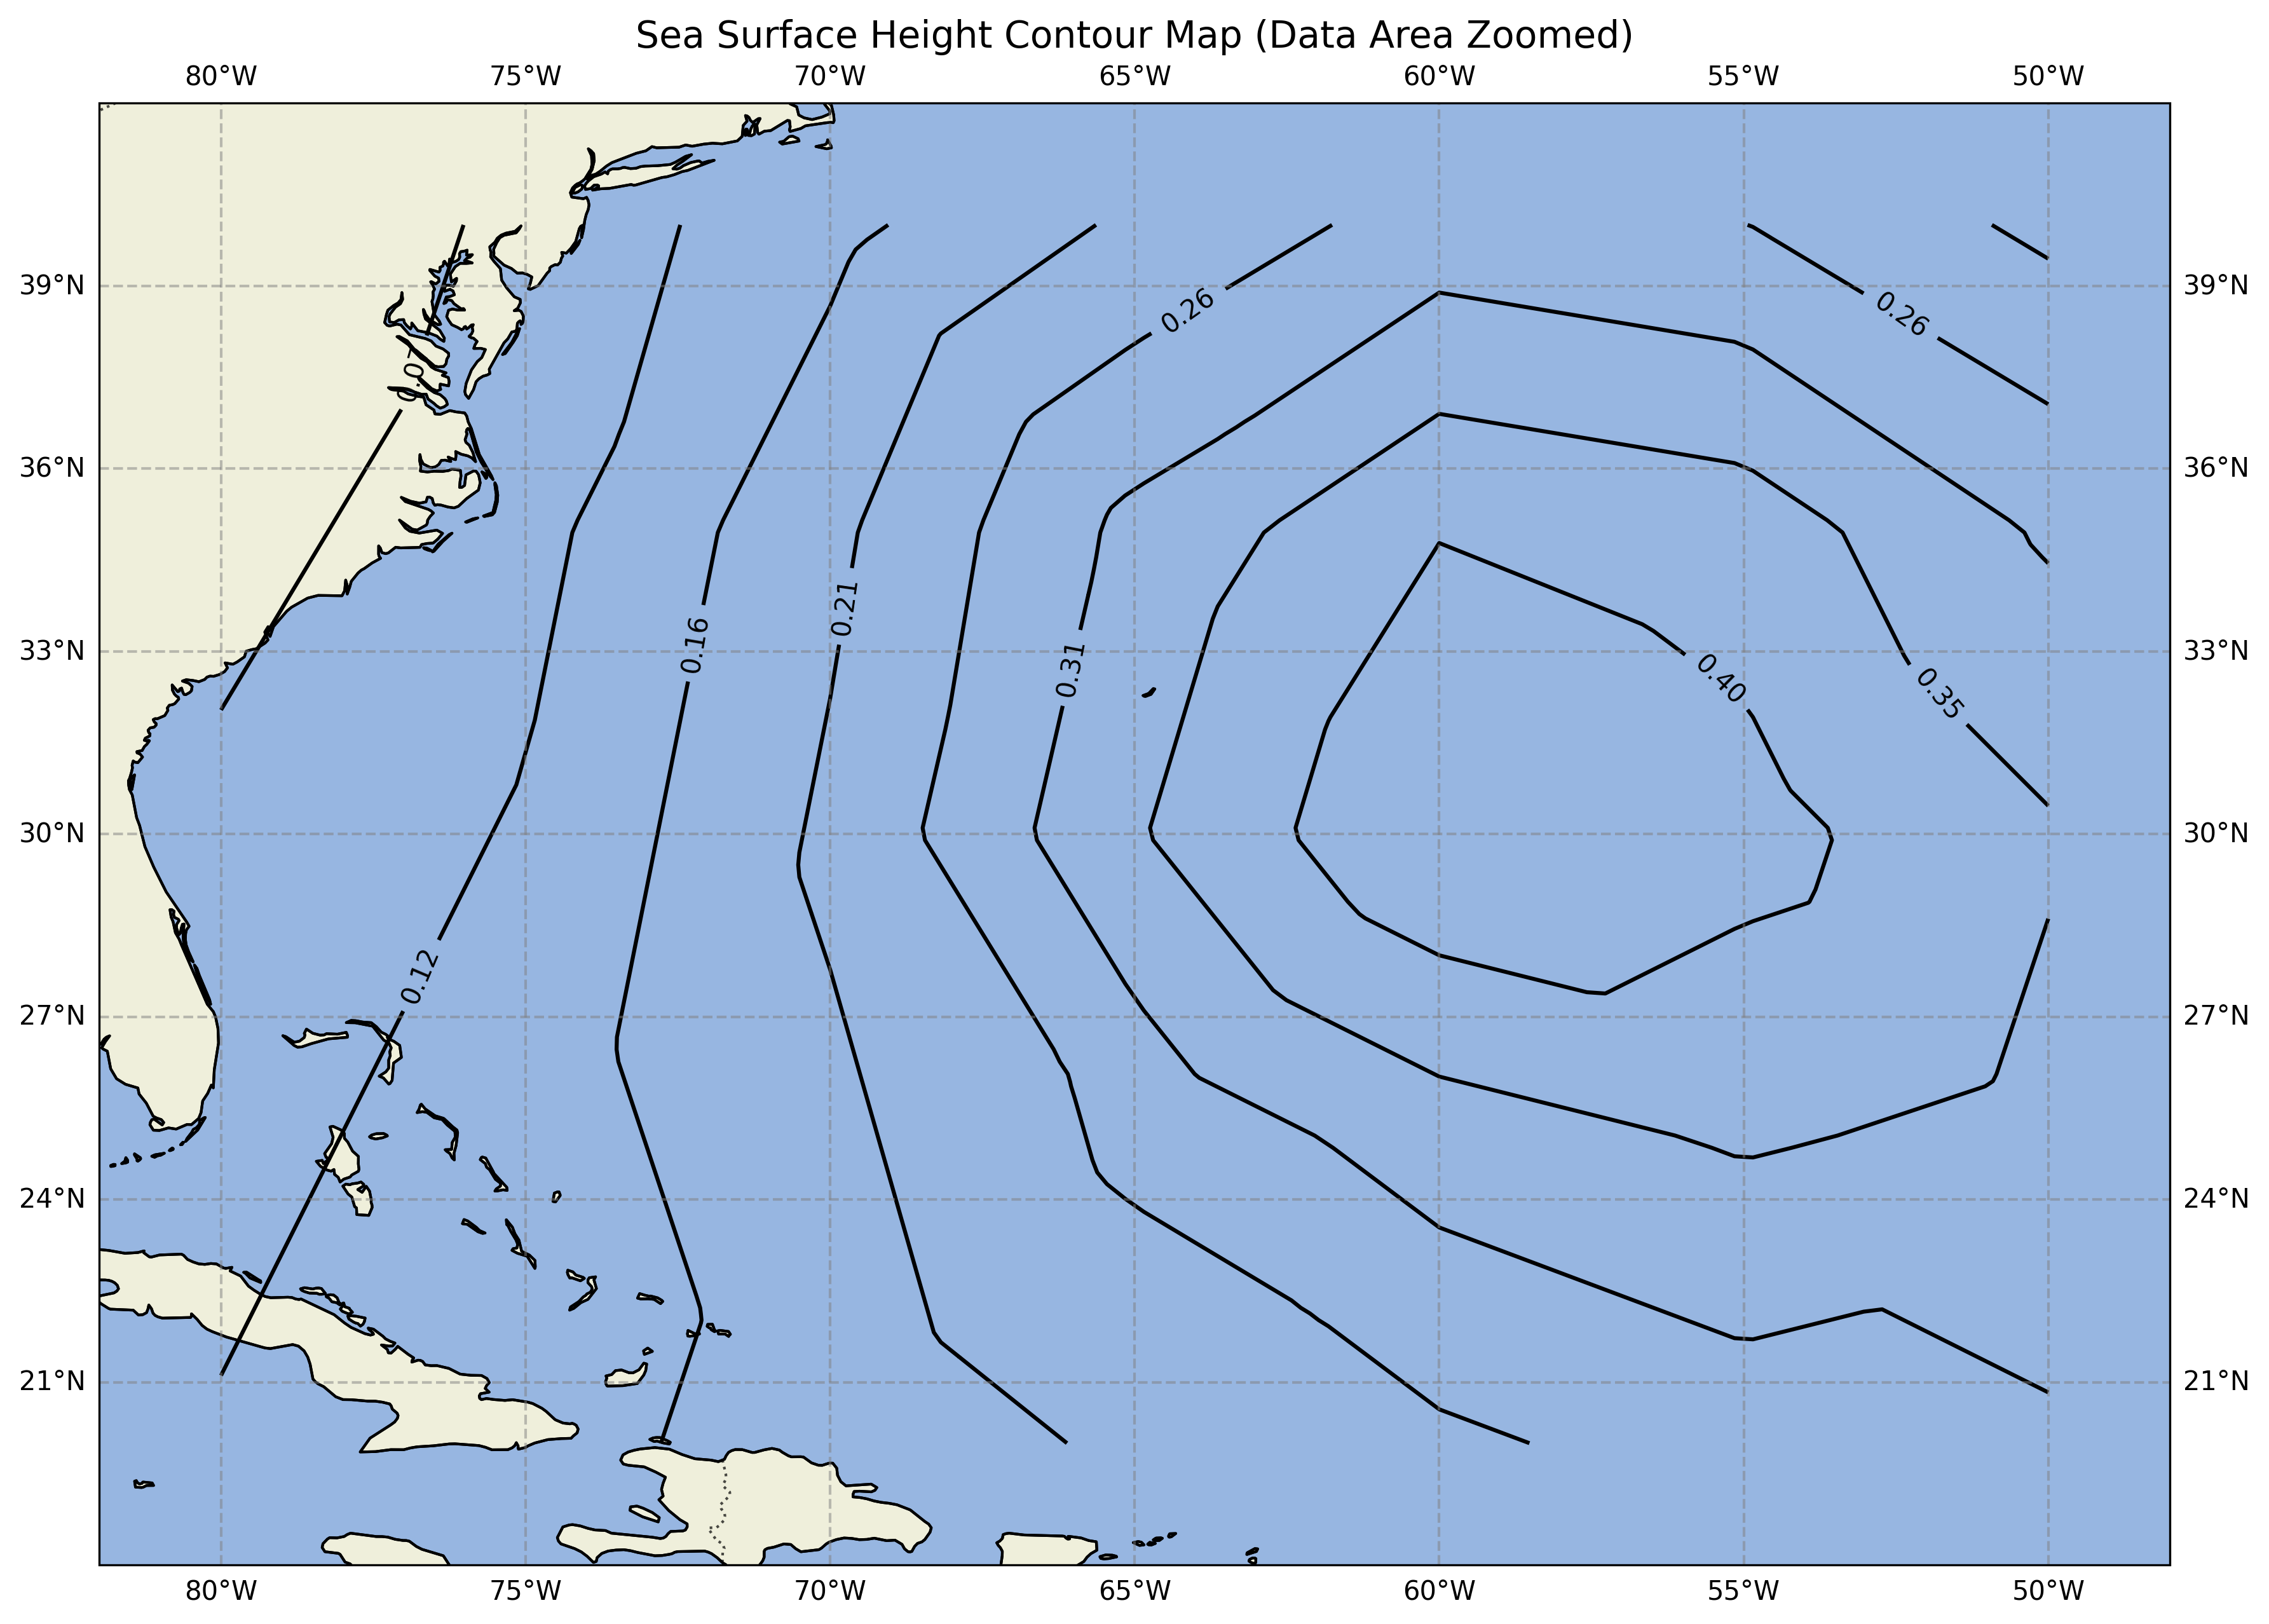

In [32]:
from IPython.display import Image
Image('ssh_contour_map.png')

In [34]:
# Install the gsw package
!pip install gsw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.4 MB/s eta 0:00:00


Second part of the exercise

- download and import gsw package
- import the TS_practicedata.csv as a pandas dataframe
- plot an empty TS (temperature-saliinity) diagram with equal denisty contours

In [36]:
# download, import gsw package
import gsw

In [40]:
import pandas as pd
df_ts = pd.read_csv('/TS_practicedata.csv')

In [ ]:
#plot an empty TS (temperature-salinity) diagram with equal density contours, using the gsw package to calculate equal density

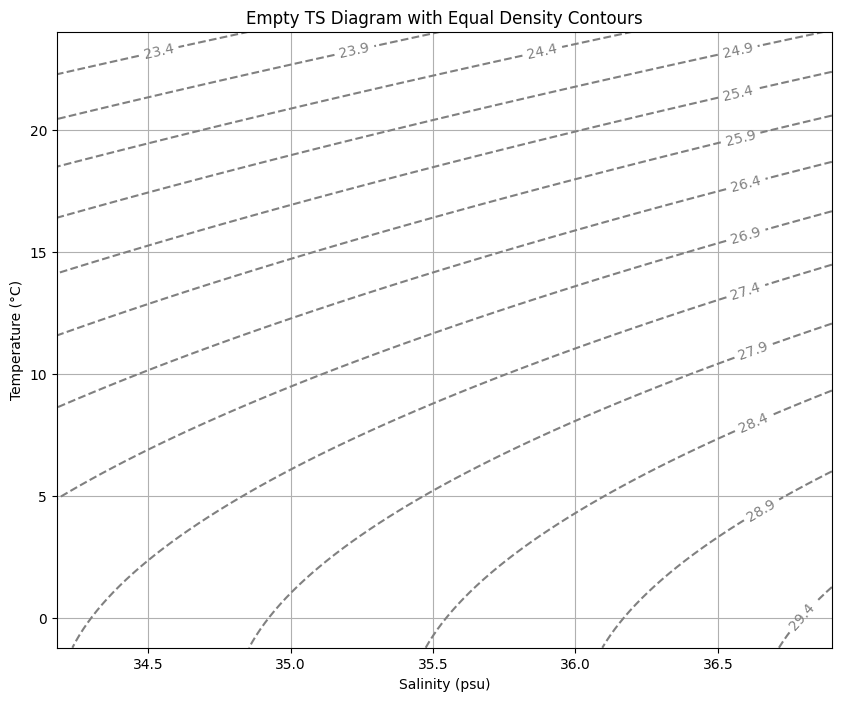

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import gsw

# Define temperature and salinity ranges based on your data, with some buffer
T_min, T_max = df_ts['temperature_C'].min() - 2, df_ts['temperature_C'].max() + 2
S_min, S_max = df_ts['salinity_psu'].min() - 0.5, df_ts['salinity_psu'].max() + 0.5

# Create a grid of potential temperature and salinity values
S_grid = np.linspace(S_min, S_max, 100)
T_grid = np.linspace(T_min, T_max, 100)

# Create meshgrid for contour plotting
SS, TT = np.meshgrid(S_grid, T_grid)

# Assuming a reference pressure of 0 dbar for calculating potential density
# Calculate potential density anomaly (sigma0) using gsw
sigma0 = gsw.density.sigma0(SS, TT)

# Define contour levels for density. You might want to adjust these.
# A common range for ocean water is 20 to 29 kg/m^3 (sigma0)
contour_levels = np.arange(sigma0.min(), sigma0.max(), 0.5)
# If the range is too small, use a default wider range
if len(contour_levels) < 5: # Ensure at least 5 contour lines
    contour_levels = np.arange(20, 29, 0.5)

# Plotting the TS Diagram
plt.figure(figsize=(10, 8))
contour = plt.contour(SS, TT, sigma0, colors='gray', linestyles='--', levels=contour_levels)
plt.clabel(contour, inline=1, fontsize=10, fmt='%1.1f')

plt.xlabel('Salinity (psu)')
plt.ylabel('Temperature (°C)')
plt.title('Empty TS Diagram with Equal Density Contours')
plt.grid(True)
plt.show()

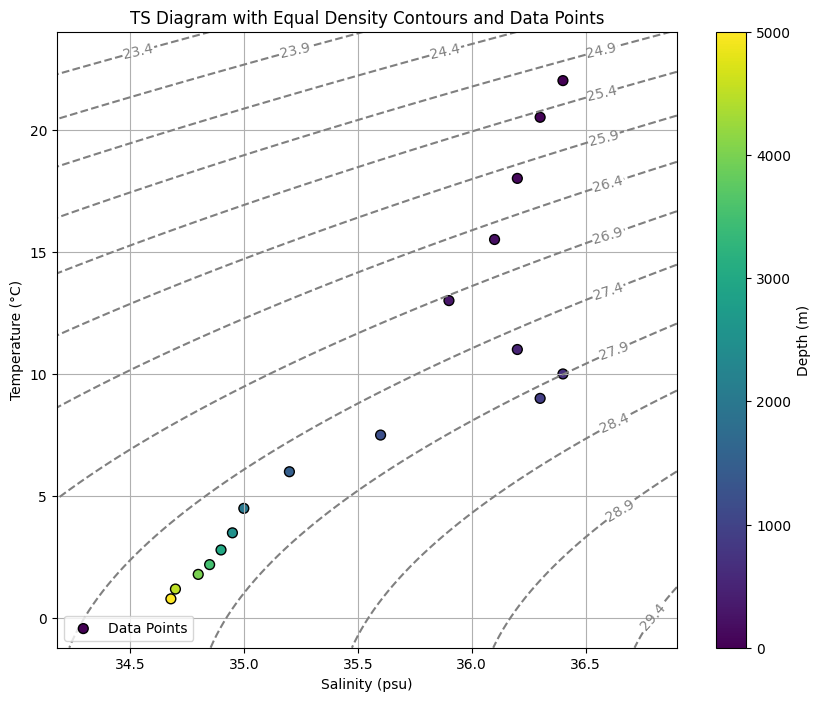

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import gsw

# Define temperature and salinity ranges based on your data, with some buffer
T_min, T_max = df_ts['temperature_C'].min() - 2, df_ts['temperature_C'].max() + 2
S_min, S_max = df_ts['salinity_psu'].min() - 0.5, df_ts['salinity_psu'].max() + 0.5

# Create a grid of potential temperature and salinity values
S_grid = np.linspace(S_min, S_max, 100)
T_grid = np.linspace(T_min, T_max, 100)

# Create meshgrid for contour plotting
SS, TT = np.meshgrid(S_grid, T_grid)

# Assuming a reference pressure of 0 dbar for calculating potential density
# Calculate potential density anomaly (sigma0) using gsw
sigma0 = gsw.density.sigma0(SS, TT)

# Define contour levels for density. You might want to adjust these.
# A common range for ocean water is 20 to 29 kg/m^3 (sigma0)
contour_levels = np.arange(sigma0.min(), sigma0.max(), 0.5)
# If the range is too small, use a default wider range
if len(contour_levels) < 5: # Ensure at least 5 contour lines
    contour_levels = np.arange(20, 29, 0.5)

# Plotting the TS Diagram
plt.figure(figsize=(10, 8))
contour = plt.contour(SS, TT, sigma0, colors='gray', linestyles='--', levels=contour_levels)
plt.clabel(contour, inline=1, fontsize=10, fmt='%1.1f')

# Plot the actual data points from df_ts
plt.scatter(df_ts['salinity_psu'], df_ts['temperature_C'], c=df_ts['depth_m'], cmap='viridis', s=50, edgecolors='k', label='Data Points')
plt.colorbar(label='Depth (m)')

plt.xlabel('Salinity (psu)')
plt.ylabel('Temperature (°C)')
plt.title('TS Diagram with Equal Density Contours and Data Points')
plt.grid(True)
plt.legend()
plt.show()

In [42]:
#plot a new empty tempature-salinity diagram and plot the imported TS_practicedata.csv data
